## 3DoF Quadrotor SCP

Imports

In [2]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg
import trajopt.utils.tools as tools
import trajopt.analysis.default_analysis as default_analysis
import trajopt.analysis.statistics as stats

from trajopt.analysis.trajplots import *
import copy

setup problem and run SCP

In [3]:
from typing import Any

def add_monte_carlo_dispersions(mission_dict, realization):
    for mc_var, mc_disp in realization.items():
        mission_dict[mc_var] = mission_dict[mc_var] + mc_disp

gen_mc_variations    = 1
save_mc_variations   = 1
save_scenario_data   = 1

example_name = "quadrotor_3dof"
mc_name = "mc1"
scenario_data_name = example_name

nominal_config  = cfg.load_configs(example_name)

mv_variations = cfg.load_mv_variations(example_name)

if gen_mc_variations:
    mc_variations = cfg.gen_mc_variations(example_name)

    if save_mc_variations:
        np.save(f"data/mc_variations/{mc_name}", mc_variations)
else:
    mc_variations = np.load(f"data/mc_variations/{mc_name}.npy", allow_pickle=True).item()

variations = {
    "method": mv_variations,
    "mission": mc_variations
}

scenario_data = {}

# loop through method variations
for name, method_variation in variations["method"].items():
    
    # initialize method sub-dictionary for scenario_data dict
    scenario_data[name] = {"method_params": {},
                                  'mc_data': [None] * (variations["mission"]["num_variations"] + 1),
                                  }

    cached_subprob = None
    
    # loop through monte-carlo mission parameter realizations (number of runs)
    for run_idx, realization in enumerate(variations["mission"]["realizations"]):
        
        # take in nominal configs
        run_config = copy.deepcopy(nominal_config)

        # set method variations
        run_config["method"] = tools.deep_update(run_config["method"], method_variation)

        # set monte carlo mission variations
        add_monte_carlo_dispersions(run_config["mission"], realization)

        # create problem instance
        problem = prob.Problem(run_config, cached_subprob)
        
        # run SCP
        problem = scp.run_scp(problem)

        # perform default analysis on this mc run and store related params
        scenario_data[name]["mc_data"][run_idx] = default_analysis.perform_default_analysis(problem)

        # # store total time for scp (used to calculate time to converge)
        # scenario_data[name]['mc_data'][run_idx] = problem.solution['t_all']
        
        # cache subproblem graph to speed up solves
        cached_subprob = None # problem.method.subprob

if save_scenario_data:
    np.save(f"data/scenario_data/{scenario_data_name}_{mc_name}", scenario_data)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Users/dan/miniconda3/envs/numpy2env/lib/python3.13/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00360.3   |   0006.7  |   2830.9   |   +0.4    |      -12.0      |    -03.2    |     -12.0   |    optimal    |   8.00   |  509.7
     02     |    00002.7   |   0008.0  |   0000.8   |   -1.2    |      -12.0      |    -04.7    |     -12.0   |    optimal    |   8.00   |  504.5
Terminated from convergence criteria!
scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: quadrotor: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   ti

In [4]:
temp = scenario_data['method1']['mc_data'][0]['iters'][-1]
print(list(temp['weights']))
print(len(temp))
for t in list(temp)[0:30]:
    print(t)
problem.indices.constraints.nonlinear_inequality['']

# file path if you wish to save LaTeX tables (eg. path to a data/statistics/mc1_stats.txt)
file = None # example: ~/acl-link/prototypes/trajopt/src/trajopt/examples/quadrotor_3dof/data/stats/mc1_stats.txt

# generate and print statistics and associated tables
# analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1', 'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale', 'w_dyn_scale', 'w_term_scale', 'W_ineq', 'W_term', 'W_dyn', 'W_plus', 'W_minus', 'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus', 'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs']
36
iter_num
z_ref
us_ref
dt_ref
t_ref
weights
conv_data
_linsys_cache
subprob
parse_time
solve_time
dz_s
dnu_s
dt_s
zs
us
dt
ts
Ts
z_minus
Ak
Bk
Bkp
Sk
cnst_path
cost
prop_time
converged
t_full
t_nl


KeyError: ''

In [10]:
# print(scenario_data['method2'])
data = {'scenario1':scenario_data}
temp = data['scenario1'];#'method2']['mc_data'][0]['iters'][-1]
print(list(temp))

['method1', 'method2']


In [14]:
PLTS1 = SCVXPLOTS(data);
PLTS1.setCurrent({'scenarios':['scenario1'],
                  'methods':['method1','method2'],
                  'runs':list(range(1000)),
                  'iters':list(range(1000))[1:]})

# state_inds = [0,1,2];
# tags = ['max_q','max_Q','max_load','terminal_cost'];
# for tag in tags:
#     tag1 = tag + '_sub'; tag2 = tag + '_nl';
#     func_args1 = ['ts','zs',None,problem];
#     func_args2 = ['t_nl','z_nl',None,problem];
#     if tag == 'max_q': func = max_q_nonjax
#     if tag == 'max_Q': func = max_Q_nonjax
#     if tag == 'max_load': func = max_load_nonjax
#     if tag == 'terminal_cost': func = terminal_cost;

#     PLTS1.calcField(tag1,func,func_args = func_args1)
#     PLTS1.calcField(tag2,func,func_args = func_args2)
    



# if True: 
    
#     tag2 = 'max_Q';    func_args = ['ts','zs',None,problem];
#     tag3 = 'max_load'; func_args = ['ts','zs',None,problem];
#     func1 = max_q_nonjax;
#     func2 = max_Q_nonjax;
#     func3 = max_load_nonjax;

#     PLTS1.calcField(tag1,func1,func_args = func_args)
#     PLTS1.calcField(tag2,func2,func_args = func_args)
#     PLTS1.calcField(tag3,func3,func_args = func_args)
if True:
    def testFunc1(x,y): return np.random.rand(1)[0];
    def testFunc2(x,y): return np.random.rand(1)[0];
    def testFunc3(x,y): return np.random.rand(1)[0];
    func_args = ['z_nl','z_nl'];
    tag1 = 'max_q';
    tag2 = 'max_Q'; 
    tag3 = 'max_load'; 

    PLTS1.calcField(tag1,testFunc1,func_args = func_args)
    PLTS1.calcField(tag2,testFunc2,func_args = func_args)
    PLTS1.calcField(tag3,testFunc2,func_args = func_args)



In [15]:

PENS = {};
# PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-','msty':'','msz':4};
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};

PENS['method1']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.1,1.],'lw':1,'ls':'-','msty':'o','msz':3};
PENS['method2']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.5,.0,.1,1.],'lw':1,'ls':'-','msty':'o','msz':3};


# Fig.5 Bank Angle vs Time (for AutoScvx)

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/2627223202.py:18: SyntaxWarning: invalid escape sequence '\s'
  ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';


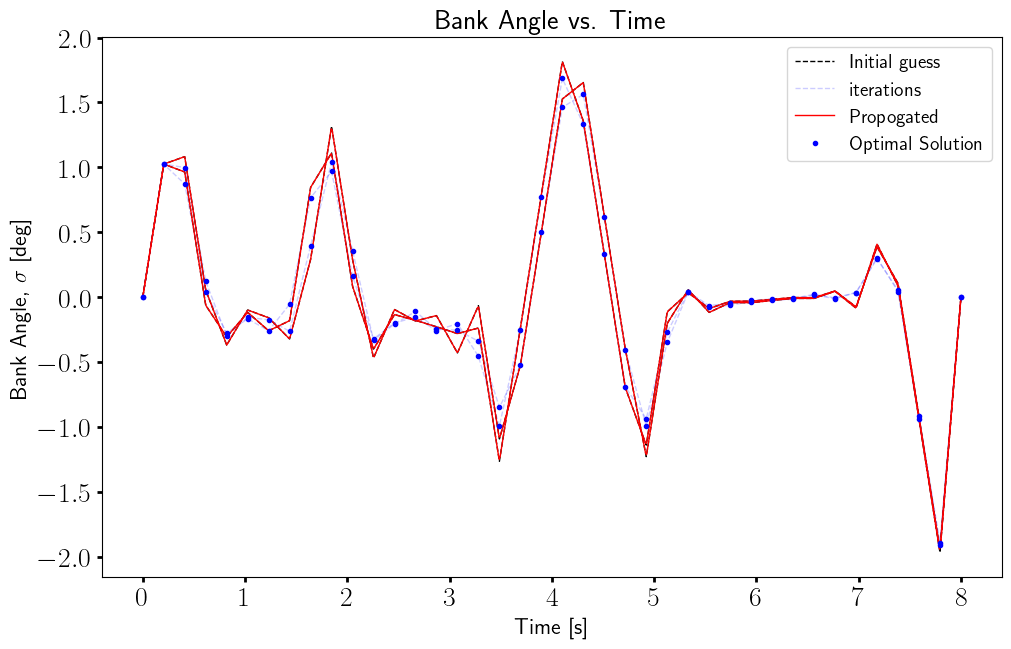

In [16]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.5,0.5,0.9,0.9];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [sind];
state_plot_inds = {sind:(0,0)};
state_names = {sind:'Bank Angle'};

titles = {}; ylabels = {};
titles[(0,0)] = 'Bank Angle vs. Time';
ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';

scenarios = ['scenario1'];
methods = ['method2']; # methods = ['method1','method2'];
lgnd = 'Fig5';

itrs_all = list(range(1000))[2:]; runs = list(range(1000));
for sind in state_inds:
    aind = state_plot_inds[sind];
    ax = axs[aind];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('u',sind),'iters':[1],'legend':lgnd};
    params2 = {'label':'iterations','x':'t','y':('u',sind),'iters':itrs_all,'legend':lgnd};
    params3 = {'label':'Propogated','x':'t_nl','y':('u_nl',sind),'iters':[-1],'legend':lgnd};
    params4 = {'label':'Optimal Solution','x':'t','y':('u',sind),'iters':[-1],'legend':lgnd};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[aind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[aind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.6

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/3955131877.py:18: SyntaxWarning: invalid escape sequence '\p'
  xlabels[0] = 'Latitude $\phi$ [deg]';
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/3955131877.py:22: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Latitude $\phi$ [deg]';


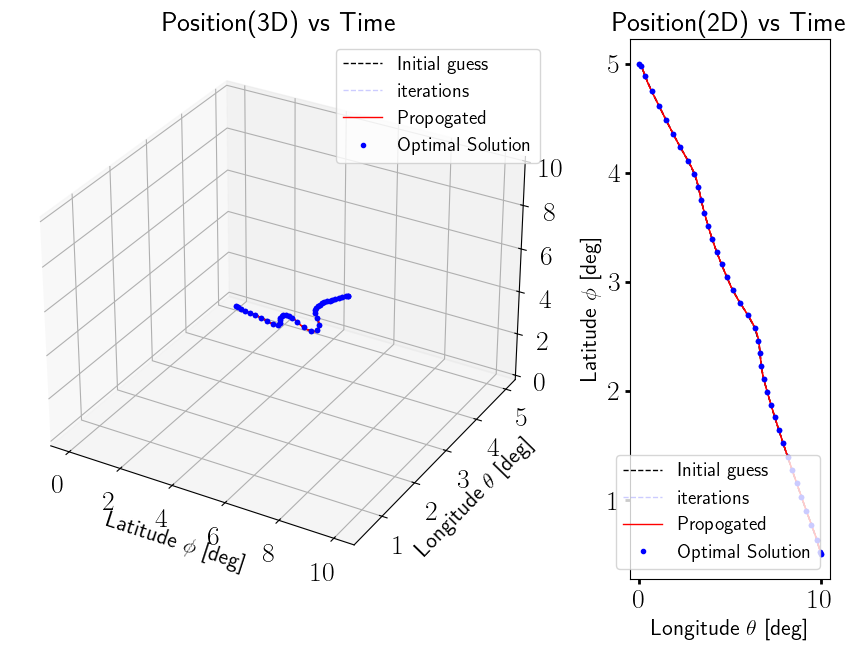

In [17]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid2D = {}; grid3D = {};
grid3D[(0,0)] = [0.05,0.05,0.6,0.9]; 
grid2D[(0,1)] = [0.70,0.05,0.2,0.9];

axs1 = PLTS1.createGrid(fig,grid = grid2D);
# axs2 = PLTS1.createGrid(fig,grid = grid3D,ins={'plt_typ':'3d'});
axs2 = {(0,0): fig.add_axes(grid3D[(0,0)],projection='3d')} # colorbar axis]
axs = {**axs1,**axs2};

state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

titles = {}; ylabels = {}; xlabels = {}; zlabels = {};
titles[0] = 'Position(3D) vs Time';
titles[1] = 'Position(2D) vs Time';

xlabels[0] = 'Latitude $\phi$ [deg]';
ylabels[0] = 'Longitude $\\theta$ [deg]';
zlabels[0] = 'Altitude $h$ [km]';

ylabels[1] = 'Latitude $\phi$ [deg]';
xlabels[1] = 'Longitude $\\theta$ [deg]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig6'
j = 1;
itrs_all = list(range(1000))[2:]; 
runs = [0]; #list(range(1000)); itrs = [-1];
ax = axs[state_plot_inds[j]];

ax = axs[(0,1)]; #state_plot_inds[j]];
sindx = 1; sindy = 2; j = 1;
# itrs_all = list(range(1000))[2:]; 
runs = [0]; itrs = [0]; 
PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})
params1 = {'label':'Initial guess','x':('z',sindx),'y':('z',sindy),'iters':[1],'legend':lgnd,};
params2 = {'label':'iterations','x':('z',sindx),'y':('z',sindy),'iters':itrs_all,'legend':lgnd};
params3 = {'label':'Propogated','x':('z_nl',sindx),'y':('z_nl',sindy),'iters':[-1],'legend':lgnd};
params4 = {'label':'Optimal Solution','x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};

PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4);     

params = {};
params['title'] = {'text':titles[1],'fontsize':20}
params['xlabel'] = {'label':xlabels[1],'fontsize':16}
params['ylabel'] = {'label':ylabels[1],'fontsize':16}
params['ticks'] = {'labelsize':20,'width':2};
PLTS1.setParams(ax,params);
PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


ax = axs[(0,0)];
sindx = 1; sindy = 2; sindz = 0; 

params1 = {'label':'Initial guess','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[1],'legend':lgnd,};
params2 = {'label':'iterations','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':itrs_all,'legend':lgnd};
params3 = {'label':'Propogated','x':('z_nl',sindx),'y':('z_nl',sindy),'z':('z_nl',sindz),'iters':[-1],'legend':lgnd};
params4 = {'label':'Optimal Solution','x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};

PLTS1.addPlot3D(ax,pen=PENS['init'],ins=params1);
PLTS1.addPlot3D(ax,pen=PENS['itr'] ,ins=params2);
PLTS1.addPlot3D(ax,pen=PENS['prop'],ins=params3); 
PLTS1.addPlot3D(ax,pen=PENS['opt'] ,ins=params4);     

params = {};
params['title'] = {'text':titles[0],'fontsize':20}
params['xlabel'] = {'label':xlabels[0],'fontsize':16}
params['ylabel'] = {'label':ylabels[0],'fontsize':16}
params['zlabel'] = {'label':zlabels[0],'fontsize':16}
params['ticks'] = {'labelsize':20,'width':2};
PLTS1.setParams(ax,params);
PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});












# Fig. 7

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/1415945579.py:25: SyntaxWarning: invalid escape sequence '\p'
  ylabels[3] = 'Heading $\psi$ [deg]';


0
3
4
5


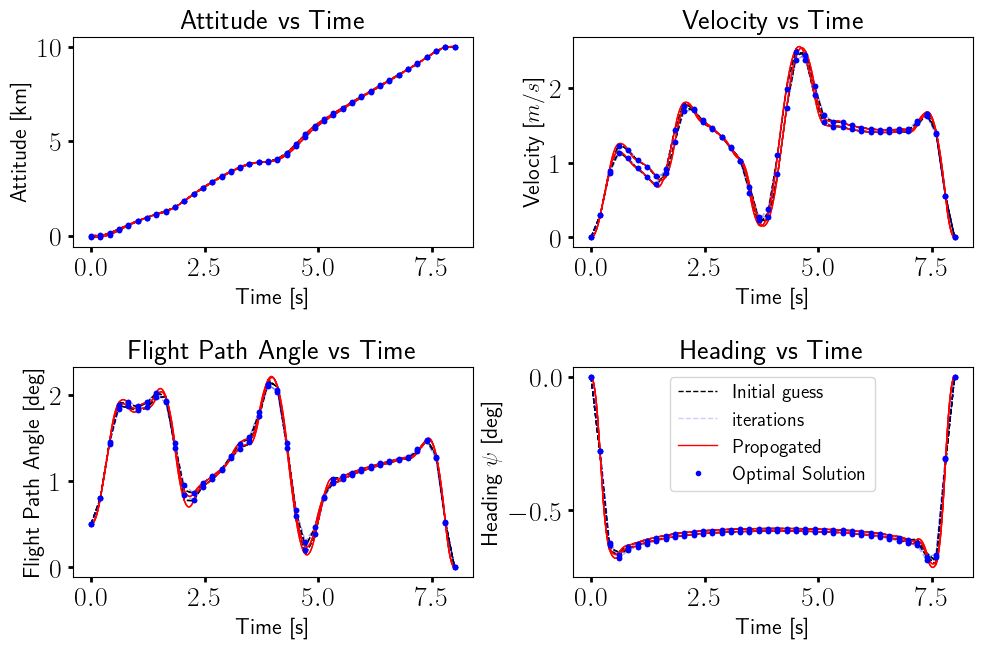

In [18]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,1)] = [0.55,0.05,0.4,0.35];
grid[(0,1)] = [0.55,0.6,0.4,0.35];
grid[(1,0)] = [0.05,0.05,0.4,0.35];
grid[(0,0)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,3,4,5] # replace with appropriate state indices
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};


titles = {}; ylabels = {};
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';

ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';
ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig7';

itrs_all = list(range(1000))[2:]; runs = list(range(1000));
for j,sind in enumerate(state_inds):
    print(sind)
    ax = axs[state_plot_inds[j]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('z',sind),'iters':[1],'legend':lgnd,};
    params2 = {'label':'iterations','x':'t','y':('z',sind),'iters':itrs_all,'legend':lgnd};
    params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':lgnd};
    params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if j == 3: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

In [19]:
# temp = PLTS1.data['scenario1']['method2']['mc_data'][0]['iters'][2]['max_load']
# print(temp)
# # print(list(temp))
# # print(temp['max_q'])

# Fig.8 heat rate etc. 

KeyError: 'max_Q_sub'

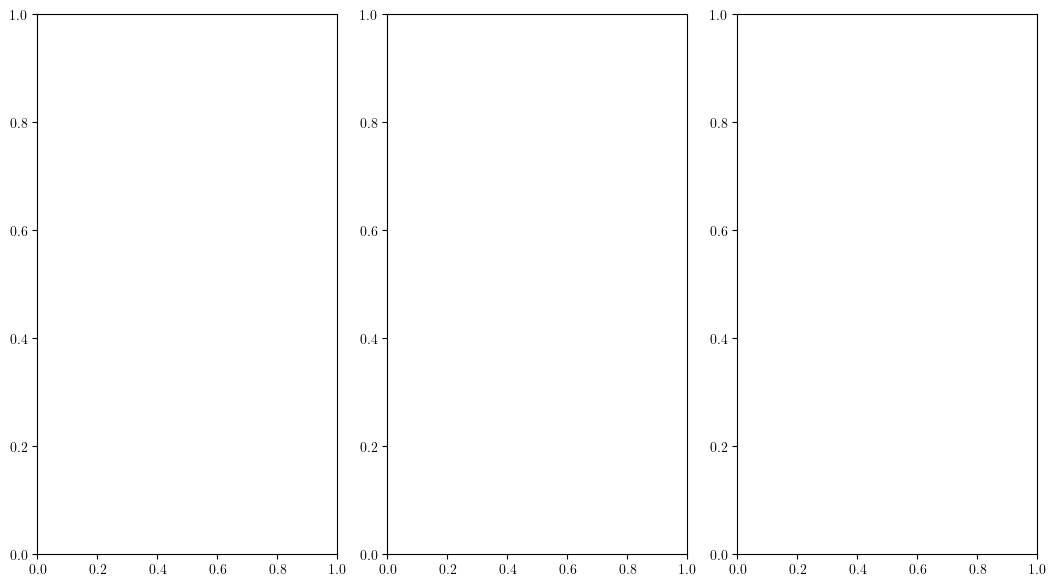

In [20]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.3,0.9];
grid[(0,1)] = [0.4,0.05,0.3,0.9];
grid[(0,2)] = [0.75,0.05,0.3,0.9];

axs = PLTS1.createGrid(fig,grid = grid);

tags = ['max_Q','max_q','max_load']
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};


titles = {}; ylabels = {};

titles[0] = 'Heat Rate Constraint';
titles[1] = 'Dynamic Pressure Constraint';
titles[2] = 'Normal Load Constraint';

ylabels[0] = 'Heating Rate [kW/$m^2$]';
ylabels[1] = 'Dynamic Pressure [kPa]';
ylabels[2] = 'Normal Load [$g\'s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig8';
itrs_all = list(range(1000))[1:]; runs = runs = list(range(1000));
for j,tag in enumerate(tags):
    
    ax = axs[state_plot_inds[j]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    # params1 = {'label':'Initial guess','x':'t','y':tag,'iters':[1],'legend':lgnd,};
    params2 = {'label':'iterations','x':'ts','y':tag + '_sub','iters':itrs_all,'legend':lgnd};
    params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
    params4 = {'label':'Optimal Solution','x':'ts','y':tag + '_sub','iters':[-1],'legend':lgnd};

    # PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

In [21]:
# temp = data['scenario1']['method2']['mc_data'][0]['iters'][2]['weights'];#params']['method']['weights']['W_dyn'];
temp = data['scenario1']['method2']['mc_data'][0]['iters'][2]['conv_data'];#['chk_feas_ineq'];#params']['method']['weights']['W_dyn'];
# ['w_cost', 'alpha_z', 'alpha_u', 'beta', 'gamma', 'eps_nonzero1',
#  'eps_nonzero2', 'wbuff', 'w_path_scale', 'w_custom_scale', 'w_nfz_scale',
#  'w_dyn_scale', 'w_term_scale',

#  'W_ineq', 'W_term', 'W_dyn', 'W_plus','W_minus',
#  'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus',

#  'wtr_z', 'wtr_u', 'w_fac_N', 'w_fac_Nm1', 'w_ctcs', 'data']


# print(temp)
# print(list(temp))
# print(temp['W_ineq'])

In [22]:

temp = data['scenario1']['method2']['mc_data'][0]['iters'][2];#['weights'];
print(temp['weights']['W_ineq'])



[[250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250. 250. 250. 250. 250.]
 [250. 250

# Fig.9 

W_ineq
dual_ineq


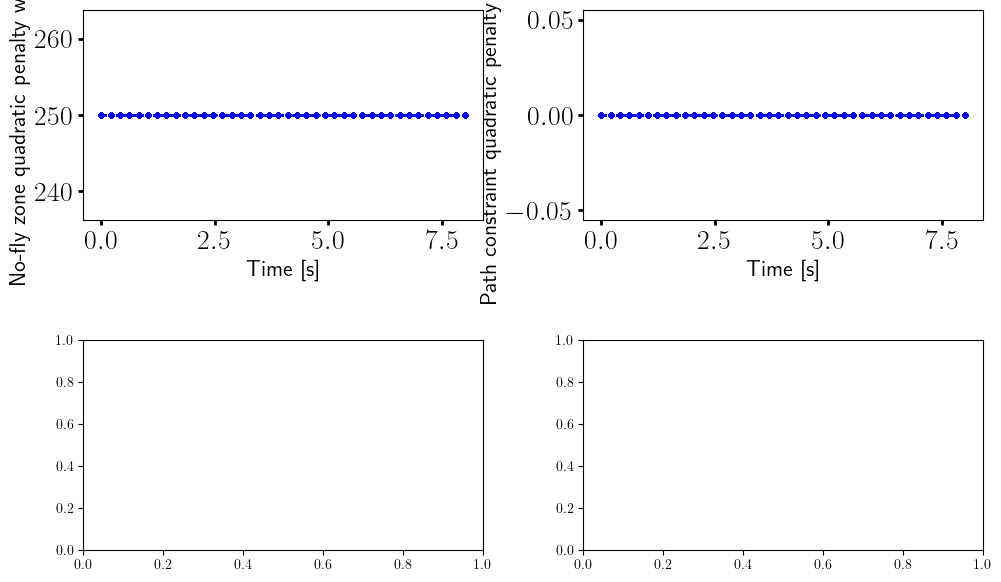

In [23]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,1)] = [0.55,0.05,0.4,0.35];
grid[(0,1)] = [0.55,0.6,0.4,0.35];
grid[(1,0)] = [0.05,0.05,0.4,0.35];
grid[(0,0)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,3,4,5] # replace with appropriate state indices
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

titles = {}; ylabels = {};
titles[0] = ''; titles[1] = ''; titles[2] = ''; titles[3] = '';

ylabels[0] = 'No-fly zone quadratic penalty weights';
ylabels[1] = 'Path constraint quadratic penalty weights';
ylabels[2] = 'No-fly zone linear penalty weights';
ylabels[3] = 'Path constraint linear penalty weights';



weights = ['W_ineq','dual_ineq']; #'W_term','W_dyn']; #,'W_plus','W_minus']
# 'W_ineq' -> path constraints
# 'W_term' -> terminal condition
# 'W_dyn', -> dynamics
# 'W_plus', 'W_minus', -> the weird quadratic 1-norm 
# 'dual_ineq', 'dual_term', 'dual_dyn', 'dual_plus', 'dual_minus', <- dual versions

scenarios = ['scenario1'];
methods = ['method1','method2'];
lgnd = 'Fig9';

itrs_all = list(range(1000))[1:]; runs = list(range(1000));
for j,weight in enumerate(weights):
    print(weight)
    ax = axs[state_plot_inds[j]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':weight,'iters':[1],'legend':lgnd,'dataloc':'weights'};
    params2 = {'label':'iterations','x':'t','y':weight,'iters':itrs_all,'legend':lgnd,'dataloc':'weights'};
    # params3 = {'label':'Propogated','x':'t_nl','y':weight,'iters':[-1],'legend':lgnd,'dataloc':'weights'};
    params4 = {'label':'Optimal Solution','x':'t','y':weight,'iters':[-1],'legend':lgnd,'dataloc':'weights'};

    # try: 
    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    # PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    # except: pass
    
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if j == 3: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.11

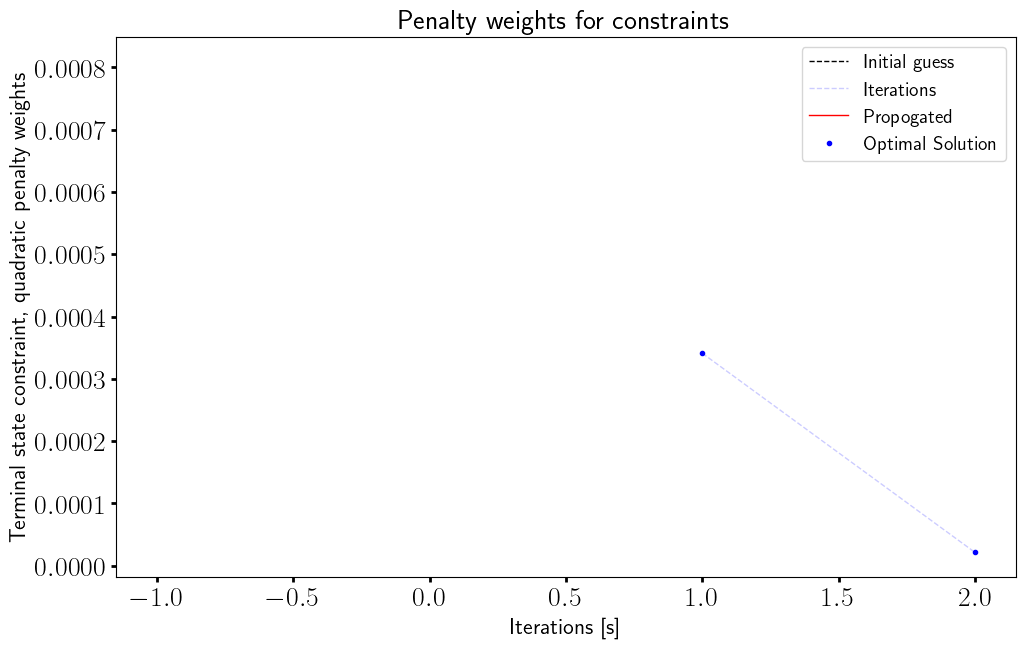

In [24]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.9,0.9];

axs = PLTS1.createGrid(fig,grid = grid);
sinds = [3] ;#tags = ['max_q','max_Q','max_load']
state_names = {0:'Term. Altitude',
               1:'Term. Longitude',
               2:'Term. Latitude',
               3:'Term. Flight Path Angle',
               4:'Term. Heading'}


lgnd = 'Fig11';
state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};

titles = {}; ylabels = {};
titles[0] = 'Penalty weights for constraints';
ylabels[0] = 'Terminal state constraint, quadratic penalty weights';

scenarios = ['scenario1'];
methods = ['method2'];

itrs_all = list(range(1000))[1:]; runs = [0];#list(range(1000));
for j,sind in enumerate(sinds):
    ax = axs[state_plot_inds[0]];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':methods,'runs':runs})

    params1 = {'label':'Initial guess','tinds':[-1],'y':('z',sind),'iters':[1],'legend':lgnd};
    params2 = {'label':'Iterations','tinds':[-1],'y':('z',sind),'iters':itrs_all,'legend':lgnd};
    params3 = {'label':'Propogated','tinds':[-1],'y':('z_nl',sind),'iters':[-1],'legend':lgnd};
    params4 = {'label':'Optimal Solution','tinds':[-1],'y':('z',sind),'iters':itrs_all,'legend':lgnd};
    PLTS1.addPlot2DIter(ax,pen=PENS['init'] ,ins=params1); 
    PLTS1.addPlot2DIter(ax,pen=PENS['itr'] ,ins=params2); 
    PLTS1.addPlot2DIter(ax,pen=PENS['prop'] ,ins=params3); 
    PLTS1.addPlot2DIter(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[0],'fontsize':20}
    params['xlabel'] = {'label':'Iterations [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[0],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.12

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/3241631624.py:18: SyntaxWarning: invalid escape sequence '\s'
  ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';


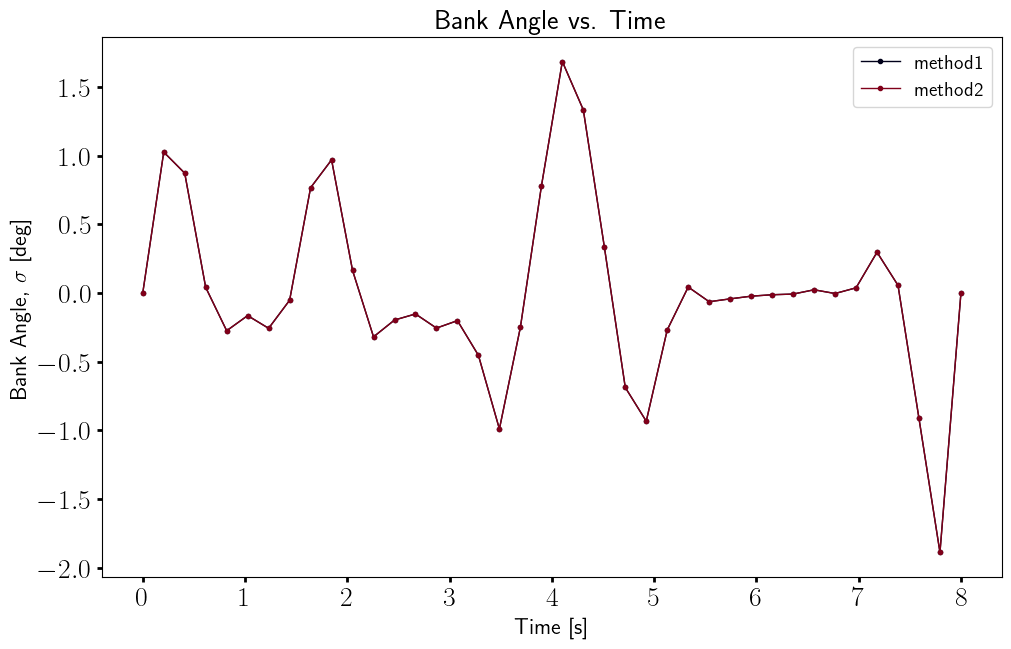

In [25]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.5,0.5,0.9,0.9];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [sind];
state_plot_inds = {sind:(0,0)};
state_names = {sind:'Bank Angle'};

titles = {}; ylabels = {};
titles[(0,0)] = 'Bank Angle vs. Time';
ylabels[(0,0)] = 'Bank Angle, $\sigma$ [deg]';

scenarios = ['scenario1'];
methods = ['method1','method2']; # methods = ['method1','method2'];

lgnd = 'Fig12';
itrs_all = list(range(1000))[2:]; runs = [0];#list(range(1000));
for method in methods:
    aind = state_plot_inds[sind];
    ax = axs[aind];
    PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

    params4 = {'label':method,'x':'t','y':('u',sind),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[aind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[aind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.13

<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/2590447015.py:19: SyntaxWarning: invalid escape sequence '\p'
  xlabels[0] = 'Latitude $\phi$ [deg]';
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/2590447015.py:23: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Latitude $\phi$ [deg]';


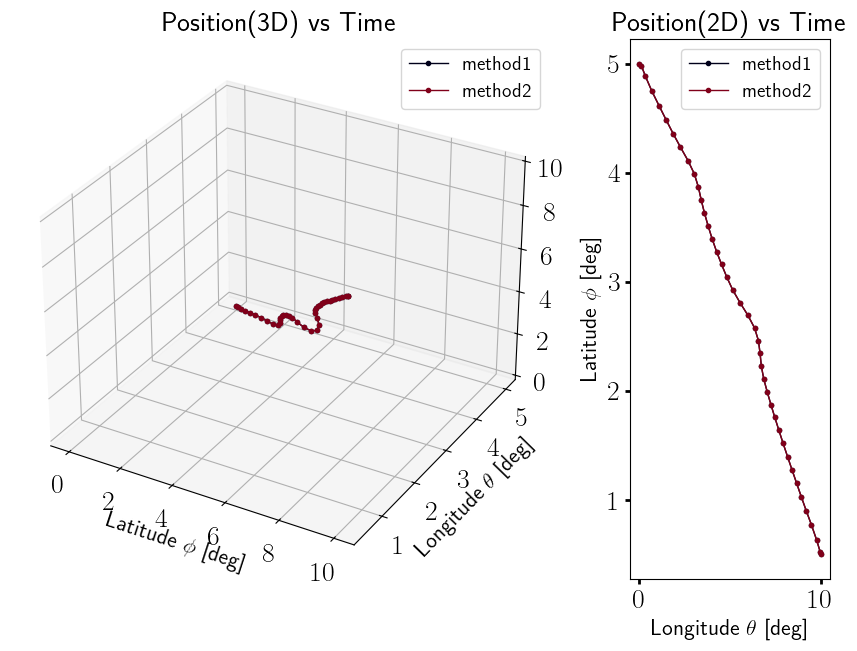

In [26]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid2D = {}; grid3D = {};
grid3D[(0,0)] = [0.05,0.05,0.6,0.9]; 
grid2D[(0,1)] = [0.70,0.05,0.2,0.9];


axs1 = PLTS1.createGrid(fig,grid = grid2D);
# axs2 = PLTS1.createGrid(fig,grid = grid3D,ins={'plt_typ':'3d'});
axs2 = {(0,0): fig.add_axes(grid3D[(0,0)],projection='3d')} # colorbar axis]
axs = {**axs1,**axs2};

state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

titles = {}; ylabels = {}; xlabels = {}; zlabels = {};
titles[0] = 'Position(3D) vs Time';
titles[1] = 'Position(2D) vs Time';

xlabels[0] = 'Latitude $\phi$ [deg]';
ylabels[0] = 'Longitude $\\theta$ [deg]';
zlabels[0] = 'Altitude $h$ [km]';

ylabels[1] = 'Latitude $\phi$ [deg]';
xlabels[1] = 'Longitude $\\theta$ [deg]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig13'
j = 1;
itrs_all = list(range(1000))[2:]; 
runs = [0]; #list(range(1000)); itrs = [-1];
ax = axs[state_plot_inds[j]];
for method in methods:
    ax = axs[(0,1)]; #state_plot_inds[j]];
    sindx = 1; sindy = 2;
    PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
    params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot2D(ax,pen=PENS[method],ins=params1);

    params = {};
    params['title'] = {'text':titles[1],'fontsize':20}
    params['xlabel'] = {'label':xlabels[1],'fontsize':16}
    params['ylabel'] = {'label':ylabels[1],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    ax = axs[(0,0)];
    sindx = 1; sindy = 2; sindz = 0; 
    params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot3D(ax,pen=PENS[method],ins=params1);
    
    params = {};
    params['title'] = {'text':titles[0],'fontsize':20}
    params['xlabel'] = {'label':xlabels[0],'fontsize':16}
    params['ylabel'] = {'label':ylabels[0],'fontsize':16}
    params['zlabel'] = {'label':zlabels[0],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

In [27]:
print(axs2)

{(0, 0): <Axes3D: title={'center': 'Position(3D) vs Time'}, xlabel='Latitude $\\phi$ [deg]', ylabel='Longitude $\\theta$ [deg]'>}


# Fig.14

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/2949379335.py:25: SyntaxWarning: invalid escape sequence '\p'
  ylabels[3] = 'Heading $\psi$ [deg]';


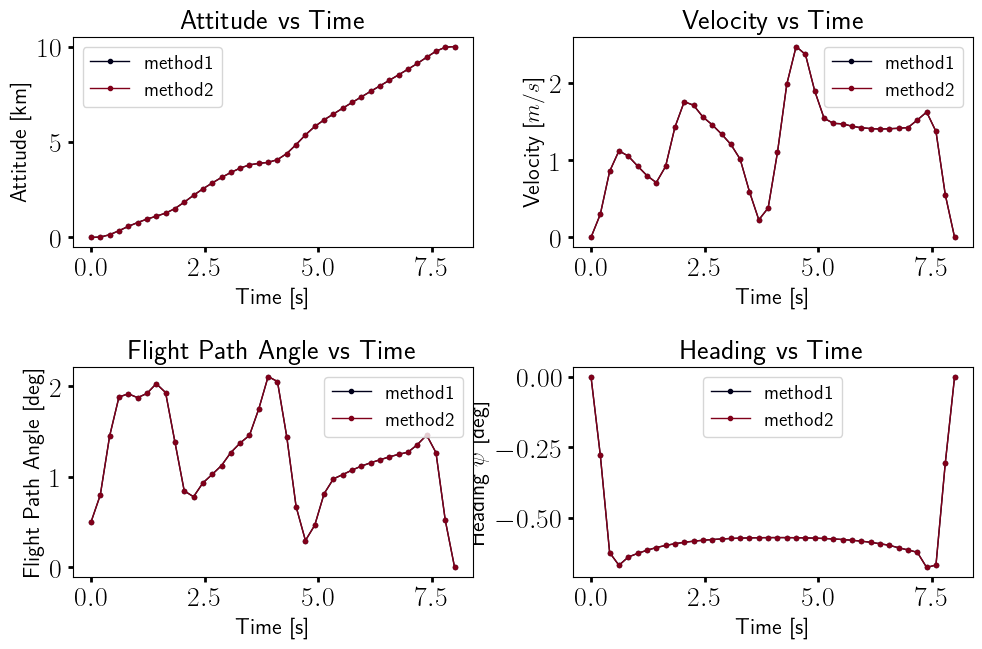

In [28]:

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,1)] = [0.55,0.05,0.4,0.35];
grid[(0,1)] = [0.55,0.6,0.4,0.35];
grid[(1,0)] = [0.05,0.05,0.4,0.35];
grid[(0,0)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,3,4,5] # replace with appropriate state indices
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};


titles = {}; ylabels = {};
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';

ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';
ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig14';
itrs_all = list(range(1000))[2:]; runs = [0];#list(range(1000));
for j,sind in enumerate(state_inds):
    for method in methods:
        aind = state_plot_inds[j];
        ax = axs[aind];
        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

        params4 = {'label':method,'x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};
        PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
        
        params = {};
        params['title'] = {'text':titles[j],'fontsize':20}
        params['xlabel'] = {'label':'Time [s]','fontsize':16}
        params['ylabel'] = {'label':ylabels[j],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
        
        PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


# Fig.15

KeyError: 'max_Q_sub'

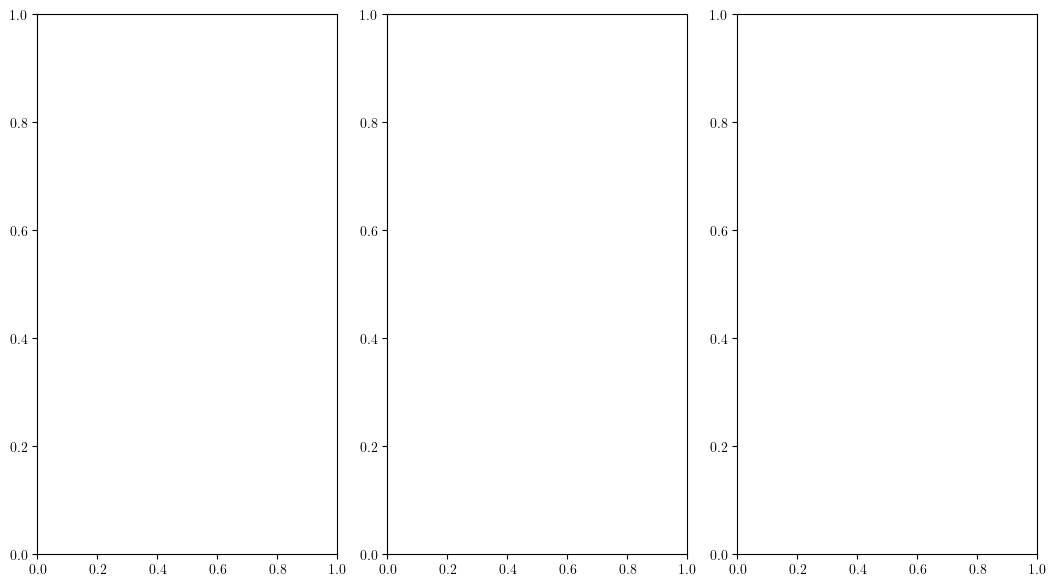

In [29]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.3,0.9];
grid[(0,1)] = [0.4,0.05,0.3,0.9];
grid[(0,2)] = [0.75,0.05,0.3,0.9];

axs = PLTS1.createGrid(fig,grid = grid);

tags = ['max_Q','max_q','max_load']
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};
titles = {}; ylabels = {};

titles[0] = 'Heat Rate Constraint';
titles[1] = 'Dynamic Pressure Constraint';
titles[2] = 'Normal Load Constraint';

ylabels[0] = 'Heating Rate [kW/$m^2$]';
ylabels[1] = 'Dynamic Pressure [kPa]';
ylabels[2] = 'Normal Load [$g\'s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];
lgnd = 'Fig15';

itrs_all = list(range(1000))[2:]; runs = [0]; #uns = list(range(1000));
for j,tag in enumerate(tags):
    for method in methods:
        ax = axs[state_plot_inds[j]];
        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

        # params1 = {'label':'Initial guess','x':'t_nl','y':tag,'iters':[1],'legend':lgnd,};
        # params2 = {'label':'iterations','x':'t_nl','y':tag,'iters':itrs_all,'legend':lgnd};
        params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
        params4 = {'label':'Optimal Solution','x':'ts','y':tag + '_sub','iters':[-1],'legend':lgnd};
        PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
    
        params = {};
        params['title'] = {'text':titles[j],'fontsize':20}
        params['xlabel'] = {'label':'Time [s]','fontsize':16}
        params['ylabel'] = {'label':ylabels[j],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
    if j == 2: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.16

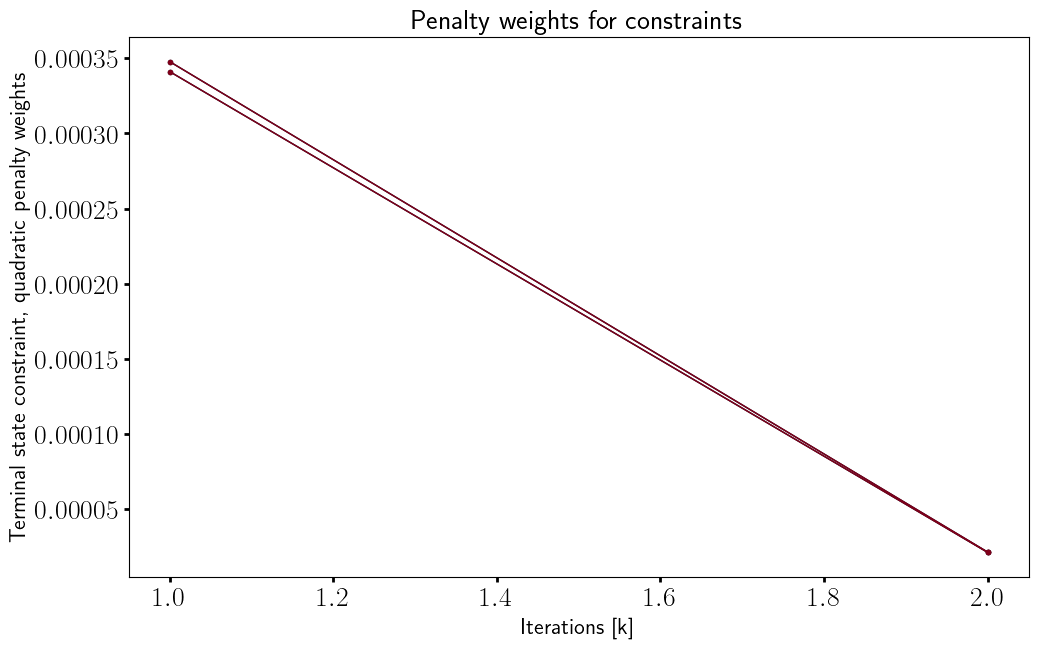

In [30]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.9,0.9];

axs = PLTS1.createGrid(fig,grid = grid);
sinds = [3] ;#tags = ['max_q','max_Q','max_load']
state_names = {0:'Terminal Velocity [m/s]'}
lgnd = 'Fig16';

titles = {}; ylabels = {};
state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};
titles[0] = 'Penalty weights for constraints';
ylabels[0] = 'Terminal state constraint, quadratic penalty weights';

scenarios = ['scenario1'];
methods = ['method1','method2'];

itrs_all = list(range(1000))[1:]; runs = list(range(1000));
for j,sind in enumerate(sinds):
    for method in methods:
        ax = axs[state_plot_inds[j]];
        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
        params1 = {'label':'Initial guess','tinds':[-1],'y':('z',sind),'iters':itrs_all,'legend':lgnd};
        PLTS1.addPlot2DIter(ax,pen=PENS[method] ,ins=params1); 
    
        params = {};
        params['title'] = {'text':titles[j],'fontsize':20}
        params['xlabel'] = {'label':'Iterations [k]','fontsize':16}
        params['ylabel'] = {'label':ylabels[j],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
    if j == 2: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


# Fig.19

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/3655267549.py:20: SyntaxWarning: invalid escape sequence '\s'
  ylabels[0] = 'Bank Angle, $\sigma$ [deg]';


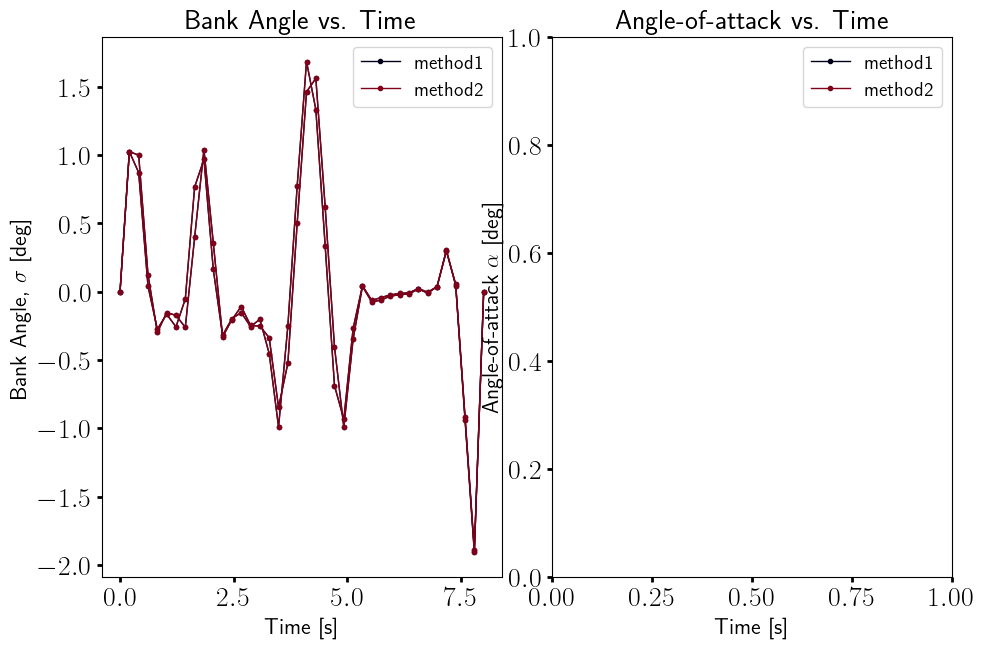

In [31]:
### TO FIX
### ================================================ ###
sind = 0; # STATE INDEX FOR BANK ANGLE 
### ================================================ ###

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.4,0.9];
grid[(0,1)] = [0.50,0.05,0.4,0.9];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,1];
state_plot_inds = {0:(0,0),1:(0,1)};
state_names = {sind:'Bank Angle'};

titles = {}; ylabels = {};
titles[0] = 'Bank Angle vs. Time';
titles[1] = 'Angle-of-attack vs. Time';
ylabels[0] = 'Bank Angle, $\sigma$ [deg]';
ylabels[1] = 'Angle-of-attack $\\alpha$ [deg]';

scenarios = ['scenario1'];
methods = ['method1','method2']; # methods = ['method1','method2'];

lgnd = 'Fig12';
itrs_all = list(range(1000))[2:]; runs = list(range(1000));
# for j,sind in enumerate(state_inds):
for method in methods:
    PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
    ax = axs[(0,0)];
    params = {'label':method,'x':'t','y':('u',0),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params); 
    # ax = axs[(0,1)];
    # params = {'label':method,'x':'t','y':('u',1),'iters':[-1],'legend':lgnd};
    # PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params); 
    

for j in [0,1]:
    ax = axs[state_plot_inds[j]];
    params = {};
    params['title'] = {'text':titles[j],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[j],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});



# Fig.20

<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/1598685341.py:19: SyntaxWarning: invalid escape sequence '\p'
  xlabels[0] = 'Latitude $\phi$ [deg]';
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/1598685341.py:23: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Latitude $\phi$ [deg]';


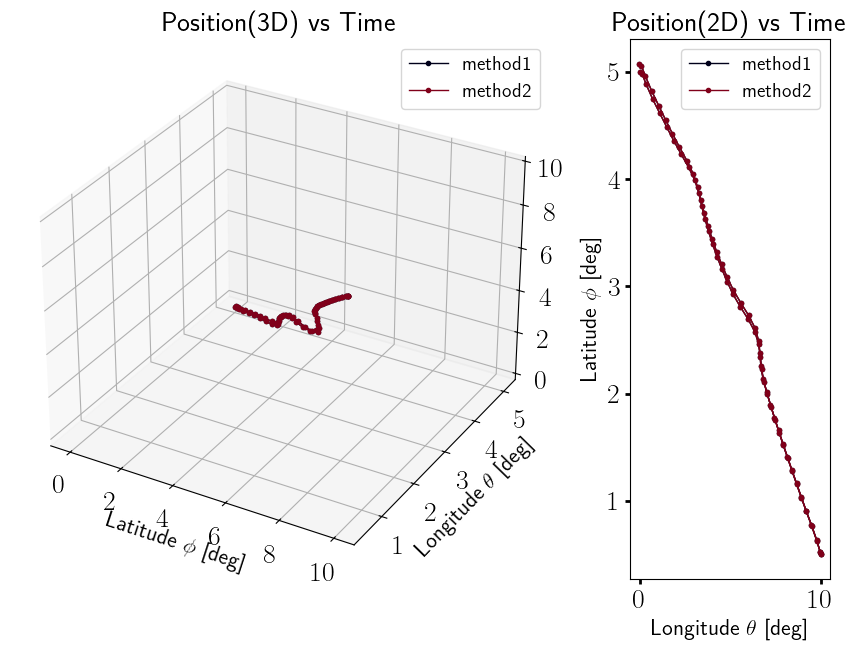

In [32]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid2D = {}; grid3D = {};
grid3D[(0,0)] = [0.05,0.05,0.6,0.9]; 
grid2D[(0,1)] = [0.70,0.05,0.2,0.9];


axs1 = PLTS1.createGrid(fig,grid = grid2D);
# axs2 = PLTS1.createGrid(fig,grid = grid3D,ins={'plt_typ':'3d'});
axs2 = {(0,0): fig.add_axes(grid3D[(0,0)],projection='3d')} # colorbar axis]
axs = {**axs1,**axs2};

state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};

titles = {}; ylabels = {}; xlabels = {}; zlabels = {};
titles[0] = 'Position(3D) vs Time';
titles[1] = 'Position(2D) vs Time';

xlabels[0] = 'Latitude $\phi$ [deg]';
ylabels[0] = 'Longitude $\\theta$ [deg]';
zlabels[0] = 'Altitude $h$ [km]';

ylabels[1] = 'Latitude $\phi$ [deg]';
xlabels[1] = 'Longitude $\\theta$ [deg]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig13'
j = 1;
itrs_all = list(range(1000))[2:]; 
runs = list(range(1000)); #itrs = [-1];
ax = axs[state_plot_inds[j]];
for method in methods:
    ax = axs[(0,1)]; #state_plot_inds[j]];
    sindx = 1; sindy = 2;
    PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})
    params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot2D(ax,pen=PENS[method],ins=params1);

    params = {};
    params['title'] = {'text':titles[1],'fontsize':20}
    params['xlabel'] = {'label':xlabels[1],'fontsize':16}
    params['ylabel'] = {'label':ylabels[1],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


    ax = axs[(0,0)];
    sindx = 1; sindy = 2; sindz = 0; 
    params1 = {'label':method,'x':('z',sindx),'y':('z',sindy),'z':('z',sindz),'iters':[-1],'legend':lgnd};
    PLTS1.addPlot3D(ax,pen=PENS[method],ins=params1);
    
    params = {};
    params['title'] = {'text':titles[0],'fontsize':20}
    params['xlabel'] = {'label':xlabels[0],'fontsize':16}
    params['ylabel'] = {'label':ylabels[0],'fontsize':16}
    params['zlabel'] = {'label':zlabels[0],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

# Fig.21

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/850159985.py:25: SyntaxWarning: invalid escape sequence '\p'
  ylabels[3] = 'Heading $\psi$ [deg]';


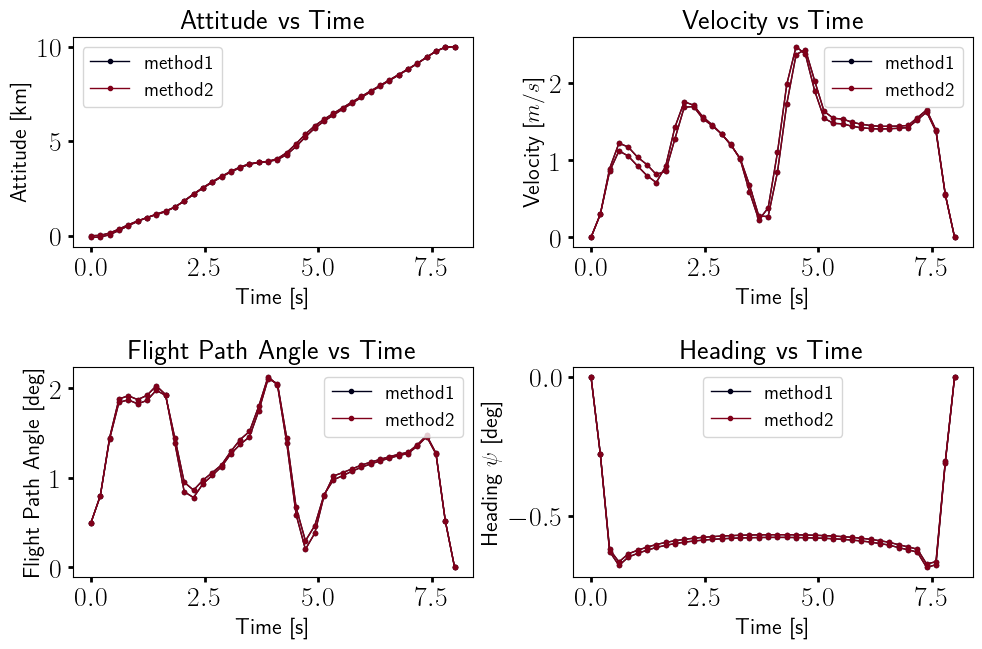

In [33]:

# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(1,1)] = [0.55,0.05,0.4,0.35];
grid[(0,1)] = [0.55,0.6,0.4,0.35];
grid[(1,0)] = [0.05,0.05,0.4,0.35];
grid[(0,0)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);

state_inds = [0,3,4,5] # replace with appropriate state indices
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};



state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};


titles = {}; ylabels = {};
titles[2] = 'Flight Path Angle vs Time';
titles[3] = 'Heading vs Time';
titles[0] = 'Attitude vs Time';
titles[1] = 'Velocity vs Time';

ylabels[2] = 'Flight Path Angle [deg]';
ylabels[3] = 'Heading $\psi$ [deg]';
ylabels[0] = 'Attitude [km]';
ylabels[1] = 'Velocity [$m/s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];

lgnd = 'Fig14';
itrs_all = list(range(1000))[1:]; runs = list(range(1000));
for j,sind in enumerate(state_inds):
    for method in methods:
        aind = state_plot_inds[j];
        ax = axs[aind];
        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

        params4 = {'label':method,'x':'t','y':('z',sind),'iters':[-1],'legend':lgnd};
        PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
        
        params = {};
        params['title'] = {'text':titles[j],'fontsize':20}
        params['xlabel'] = {'label':'Time [s]','fontsize':16}
        params['ylabel'] = {'label':ylabels[j],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
        
        PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});


# Fig.22

KeyError: 'max_Q_sub'

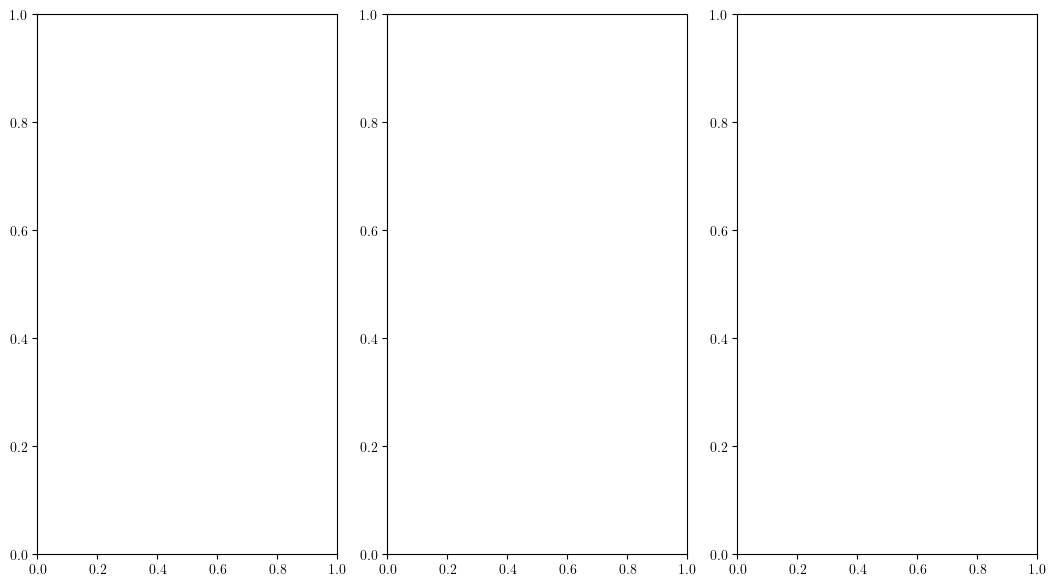

In [34]:
# grid = PLTS1.specGrid(typ='2x2'); 
fig = plt.figure(figsize=(10,6));
grid = {};
grid[(0,0)] = [0.05,0.05,0.3,0.9];
grid[(0,1)] = [0.4,0.05,0.3,0.9];
grid[(0,2)] = [0.75,0.05,0.3,0.9];

axs = PLTS1.createGrid(fig,grid = grid);

tags = ['max_Q','max_q','max_load']
state_names = {0:'Altitude',1:'Velocity',2:'Flight Path Angle',3:'Heading'};

state_plot_inds = {0:(0,0),1:(0,1),2:(0,2)};
titles = {}; ylabels = {};

titles[0] = 'Heat Rate Constraint';
titles[1] = 'Dynamic Pressure Constraint';
titles[2] = 'Normal Load Constraint';

ylabels[0] = 'Heating Rate [kW/$m^2$]';
ylabels[1] = 'Dynamic Pressure [kPa]';
ylabels[2] = 'Normal Load [$g\'s$]';

scenarios = ['scenario1'];
methods = ['method1','method2'];
lgnd = 'Fig15';

itrs_all = list(range(1000))[1:]; runs = list(range(1000));
for j,tag in enumerate(tags):
    for method in methods:
        ax = axs[state_plot_inds[j]];
        PLTS1.setCurrent({'scenarios':scenarios,'methods':[method],'runs':runs})

        # params1 = {'label':'Initial guess','x':'t_nl','y':tag,'iters':[1],'legend':lgnd,};
        # params2 = {'label':'iterations','x':'t_nl','y':tag,'iters':itrs_all,'legend':lgnd};
        params3 = {'label':'Propogated','x':'t_nl','y':tag + '_nl','iters':[-1],'legend':lgnd};
        params4 = {'label':'Optimal Solution','x':'ts','y':tag + '_sub','iters':[-1],'legend':lgnd};
        PLTS1.addPlot2D(ax,pen=PENS[method] ,ins=params4); 
    
        params = {};
        params['title'] = {'text':titles[j],'fontsize':20}
        params['xlabel'] = {'label':'Time [s]','fontsize':16}
        params['ylabel'] = {'label':ylabels[j],'fontsize':16}
        params['ticks'] = {'labelsize':20,'width':2};
        PLTS1.setParams(ax,params);
    if j == 2: PLTS1.addLegend(ax,lgnd,ins={'fontsize':14,'loc':'best'});

run statistical analysis

# New Plots

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9h/62cp03kd3gv3jr3ny97ftngr0000gn/T/ipykernel_92690/751309488.py:29: SyntaxWarning: invalid escape sequence '\p'
  ylabels[1] = 'Heading r$\psi$ [deg]';


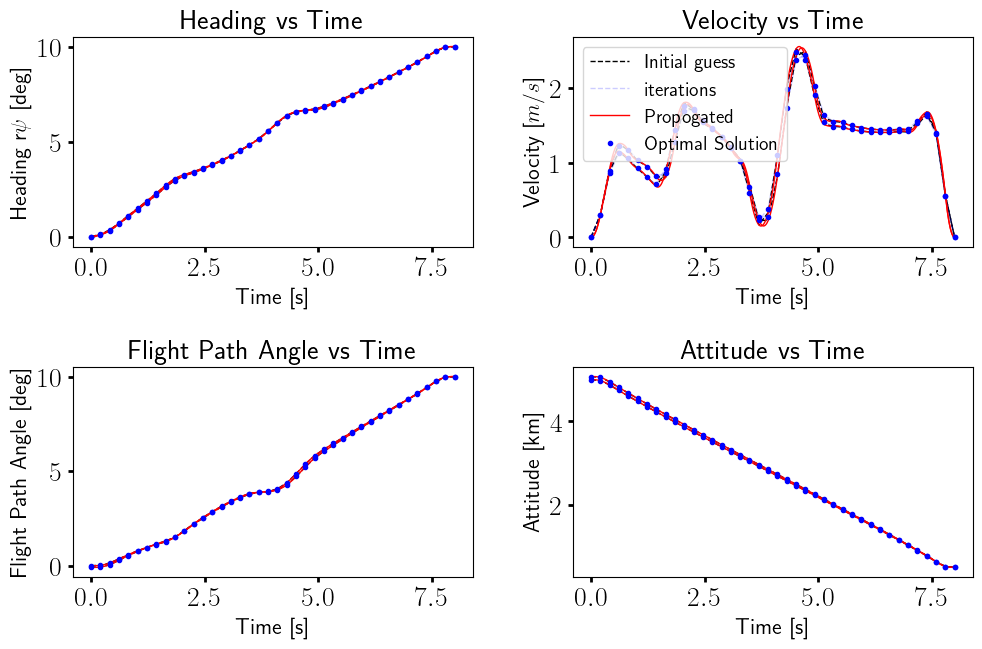

In [35]:
fig = plt.figure(figsize=(10,6));
PLTS1 = SCVXPLOTS(data);
grid = {};
grid[(1,0)] = [0.55,0.05,0.4,0.35]; grid[(1,1)] = [0.55,0.6,0.4,0.35];
grid[(0,0)] = [0.05,0.05,0.4,0.35]; grid[(0,1)] = [0.05,0.6,0.4,0.35];
axs = PLTS1.createGrid(fig,grid = grid);


# grid = PLTS1.specGrid(typ='2x2'); 
PENS = {};
# PENS['z'] = {'frgba':[0,0,0,0.1],'lrgba':[0,0,0,0.1],'lw':2,'ls':'-','msty':'','msz':4};
PENS['init'] = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['itr']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,.2],'lw':1,'ls':'--','msty':'' ,'msz':3};
PENS['opt']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,1.,1.],'lw':1,'ls':''  ,'msty':'o','msz':3};
PENS['prop'] = {'frgba':[.0,.0,.0,.1],'lrgba':[1.,.0,.0,1.],'lw':1,'ls':'-' ,'msty':'' ,'msz':3};
PENS['ref']  = {'frgba':[.0,.0,.0,.1],'lrgba':[.0,.0,.0,1.],'lw':1,'ls':'--','msty':'*','msz':3};

## STATE PLOT OVER ITERATIONS ## STATE PLOT OVER ITERATIONS
state_plot_inds = {0:(0,0),1:(0,1),2:(1,0),3:(1,1)};
state_names = {0:'x-position',1:'y-position',2:'x-velocity',3:'y-velocity'};

titles = {}; ylabels = {};
titles[0] = 'Flight Path Angle vs Time';
titles[1] = 'Heading vs Time';
titles[2] = 'Attitude vs Time';
titles[3] = 'Velocity vs Time';

ylabels[0] = 'Flight Path Angle [deg]';
ylabels[1] = 'Heading r$\psi$ [deg]';
ylabels[2] = 'Attitude [km]';
ylabels[3] = 'Velocity [$m/s$]';

itrs_all = list(range(1000))[2:]; runs = [0,1,2,3,4]; state_inds = [0,1,2,3];
for sind in state_inds:
    ax = axs[state_plot_inds[sind]];
    PLTS1.setCurrent({'scenarios':['scenario1'],'methods':['method1'],'runs':runs})

    params1 = {'label':'Initial guess','x':'t','y':('z',sind),'iters':[1],'legend':sind,};
    params2 = {'label':'iterations','x':'t','y':('z',sind),'iters':itrs_all,'legend':sind};
    params3 = {'label':'Propogated','x':'t_nl','y':('z_nl',sind),'iters':[-1],'legend':sind};
    params4 = {'label':'Optimal Solution','x':'t','y':('z',sind),'iters':[-1],'legend':sind};

    PLTS1.addPlot2D(ax,pen=PENS['init'],ins=params1);
    PLTS1.addPlot2D(ax,pen=PENS['itr'] ,ins=params2);
    PLTS1.addPlot2D(ax,pen=PENS['prop'],ins=params3); 
    PLTS1.addPlot2D(ax,pen=PENS['opt'] ,ins=params4); 
    
    params = {};
    params['title'] = {'text':titles[sind],'fontsize':20}
    params['xlabel'] = {'label':'Time [s]','fontsize':16}
    params['ylabel'] = {'label':ylabels[sind],'fontsize':16}
    params['ticks'] = {'labelsize':20,'width':2};
    PLTS1.setParams(ax,params);
    if sind == 3: PLTS1.addLegend(ax,sind,ins={'fontsize':14,'loc':'best'});

make plots

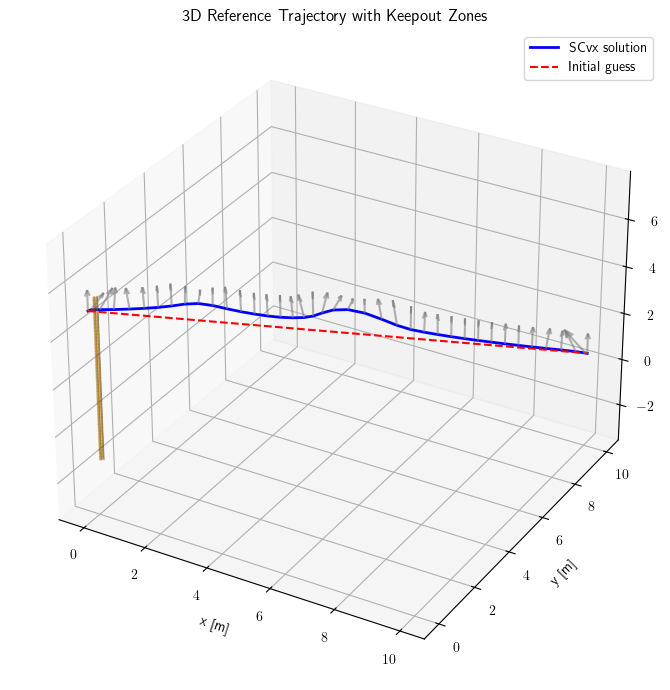

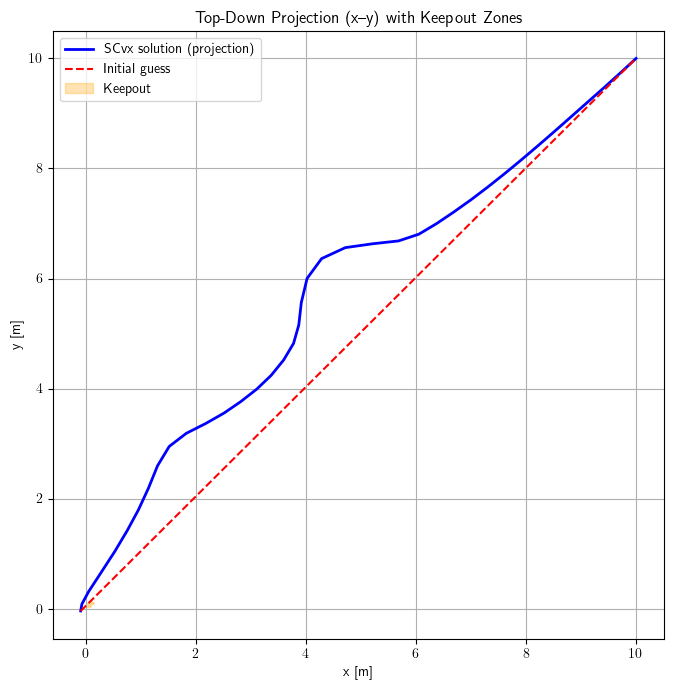

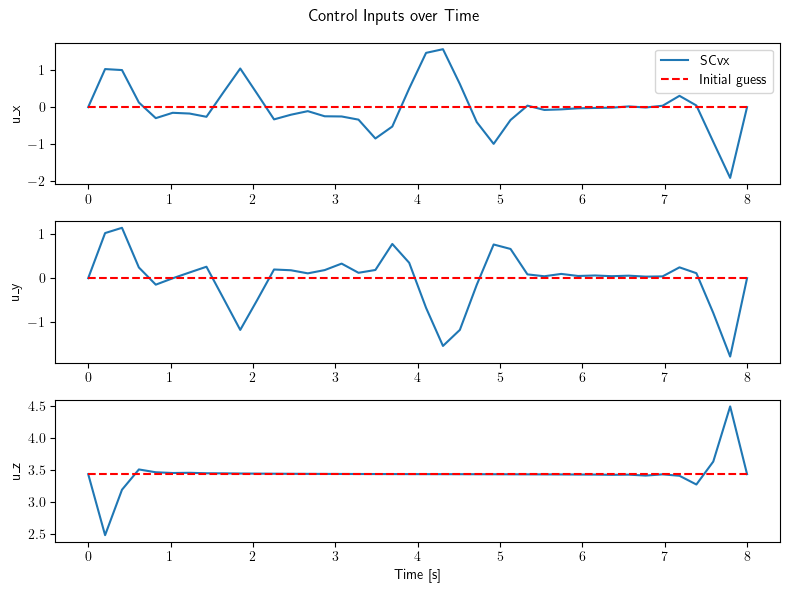

In [36]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
# run this once per notebook session
#%matplotlib widget

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

t_init = method.t_init
z_init = method.z_init
nu_init = method.nu_init
x_init  = z_init[:, 0]
y_init  = z_init[:, 1]
z_init  = z_init[:, 2]

t_opt  = problem.solution["ts"]
z_opt  = problem.solution["zs"]
nu_opt  = problem.solution["us"]

# ============================================================
# 3D Trajectory Plot
# ============================================================
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# --- Trajectories ---
ax.plot(z_opt[:, 0], z_opt[:, 1], z_opt[:, 2],
        'b-', linewidth=2, label="SCvx solution")
ax.plot(x_init, y_init, z_init,
        'r--', linewidth=1.5, label="Initial guess")

# --- Thrust vectors (downsampled for clarity) ---
nu_opt_scaled = 0.25 * nu_opt
skip = max(1, len(z_opt) // 25)
ax.quiver(
    z_opt[::skip, 0], z_opt[::skip, 1], z_opt[::skip, 2],
    nu_opt_scaled[::skip, 0], nu_opt_scaled[::skip, 1], nu_opt_scaled[::skip, 2],
    length=1.0, normalize=False, color='gray', alpha=0.6
)

# ============================================================
# Cylindrical Keepout Zones
# ============================================================
n_nfz = mission.n_nfz
z_traj_max = np.max(z_opt[:, 2])
z_traj_min = np.min(z_opt[:, 2])
height = (z_traj_max - z_traj_min) * 1.5  # cylinders taller than trajectory
z_bottom = z_traj_min - 0.25 * height
z_top = z_bottom + height

for i in range(n_nfz):
    xc = mission.obs['xc'][i] / method.nondim['nang']
    yc = mission.obs['yc'][i] / method.nondim['nang']
    rc = mission.obs['rc'][i] / method.nondim['nang']

    s = np.linspace(0, 2 * np.pi, 100)
    z = np.linspace(z_bottom, z_top, 50)
    S, Z = np.meshgrid(s, z)
    X = xc + rc * np.cos(S)
    Y = yc + rc * np.sin(S)
    ax.plot_surface(X, Y, Z, color='orange', alpha=0.3, linewidth=0, shade=True)

# ============================================================
# Equal Axis Scaling
# ============================================================
def set_axes_equal(ax):
    """Make 3D axes have equal scale."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    max_range = max([x_range, y_range, z_range]) / 2.0
    mid_x = np.mean(x_limits)
    mid_y = np.mean(y_limits)
    mid_z = np.mean(z_limits)
    ax.set_xlim3d([mid_x - max_range, mid_x + max_range])
    ax.set_ylim3d([mid_y - max_range, mid_y + max_range])
    ax.set_zlim3d([mid_z - max_range, mid_z + max_range])

set_axes_equal(ax)

# --- Labels, Legend ---
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("3D Reference Trajectory with Keepout Zones")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Top-Down Projection (x–y plane)
# ============================================================
fig, ax2d = plt.subplots(figsize=(7, 7))

# Plot trajectory footprints
ax2d.plot(z_opt[:, 0], z_opt[:, 1], 'b-', linewidth=2, label="SCvx solution (projection)")
ax2d.plot(x_init, y_init, 'r--', linewidth=1.5, label="Initial guess")

# Plot circular obstacle projections
for i in range(n_nfz):
    xc = mission.obs['xc'][i] / method.nondim['nang']
    yc = mission.obs['yc'][i] / method.nondim['nang']
    rc = mission.obs['rc'][i] / method.nondim['nang']
    circle = plt.Circle((xc, yc), rc, color='orange', alpha=0.3, label="Keepout" if i == 0 else None)
    ax2d.add_patch(circle)

ax2d.set_aspect('equal', adjustable='box')
ax2d.set_xlabel("x [m]")
ax2d.set_ylabel("y [m]")
ax2d.set_title("Top-Down Projection (x–y) with Keepout Zones")
ax2d.grid(True)
ax2d.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2D Control vs Time Plot
# ============================================================
fig = plt.figure(figsize=(8, 6))
ax_1 = fig.add_subplot(311)
ax_2 = fig.add_subplot(312)
ax_3 = fig.add_subplot(313)

ax_1.plot(t_opt, nu_opt[:, 0], label="SCvx")
ax_1.plot(t_init, nu_init[:, 0], 'r--', label="Initial guess")
ax_1.set_ylabel("u_x")

ax_2.plot(t_opt, nu_opt[:, 1])
ax_2.plot(t_init, nu_init[:, 1], 'r--')
ax_2.set_ylabel("u_y")

ax_3.plot(t_opt, nu_opt[:, 2])
ax_3.plot(t_init, nu_init[:, 2], 'r--')
ax_3.set_ylabel("u_z")
ax_3.set_xlabel("Time [s]")

ax_1.legend()
plt.suptitle("Control Inputs over Time")
plt.tight_layout()
plt.show()